In [2]:
!pip3 install statsmodels

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 10.0 MB 6.1 MB/s eta 0:00:01
     |████████████████████████████████| 233 kB 10.7 MB/s eta 0:00:01
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


In [73]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import json
from pathlib import Path
from scipy.optimize import curve_fit
import statsmodels.api as sm

# Repo root: when run from figures_notebooks/, go up one level
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'figures_notebooks' else Path.cwd()

In [123]:
def _load_ml_data_from_ml_data_folder(n, noise_type, gamma, stat_type, ml_alpha_pattern):
    """
    Load ML accuracy from ml_data via scenario1_train_results.json (same as plot_method_centric_raw).
    Returns (mean_data, yerr) with 14 points: interpolate from 7 (k, acc) to k_target.
    """
    k_target = np.array([0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1])
    channel_type = 'thermal' if noise_type == 'relaxation' else noise_type  # dephasing, depolarizing
    q_suffix = 'q_11_12' if n >= 11 else 'q_5_10'
    if ml_alpha_pattern == 'all_ones':
        exp_name = f"exp_s1_fixed_alpha_all_ones_fixed_y_all_zeros_{q_suffix}"
    else:
        exp_name = f"exp_s1_fixed_alpha_half_ones_leading_fixed_y_all_zeros_{q_suffix}"
    results_file = REPO_ROOT / "ml_data" / exp_name / "scenario1_train_results.json"
    if not results_file.exists():
        raise FileNotFoundError(f"Not found: {results_file}")
    with open(results_file) as f:
        data = json.load(f)
    for run in data['runs']:
        meta = run['meta']
        if meta['n'] != n:
            continue
        cc = meta['channel_config']
        if cc['type'] != channel_type or cc['strength'] != gamma:
            continue
        k_list, y_list, q1_list, q3_list = [], [], [], []
        for per in run['per_nps']:
            nps = per['nps']
            k_list.append(np.log2(nps) / n)
            accs = [r['logreg']['val']['acc'] for r in per['independent_runs']['per_run']]
            med = float(np.median(accs))
            q1, q3 = np.percentile(accs, [25, 75])
            y_list.append(med)
            q1_list.append(q1)
            q3_list.append(q3)
        k_arr = np.array(k_list)
        mean_data = np.interp(k_target, k_arr, np.array(y_list))
        lower_data = np.interp(k_target, k_arr, np.array(q1_list))
        higher_data = np.interp(k_target, k_arr, np.array(q3_list))
        yerr = [lower_data, higher_data]
        return mean_data, yerr
    raise FileNotFoundError(f"No run for n={n}, {noise_type}, gamma={gamma} in {results_file}")

def get_data_to_plot_alphas_2(n, noise_type, gamma, method_type='hypergraph', stat_type='iqr', ml_alpha_pattern='all_ones'):
    """
    Load data for given (n, noise_type, gamma).
    For method_type='ml': loads from ml_data folder (all_ones or half_ones_leading exp).
    For hypergraph/shadow_surrogates: loads from paper_data_2.
    """
    if method_type == 'ml':
        try:
            return _load_ml_data_from_ml_data_folder(n, noise_type, gamma, stat_type, ml_alpha_pattern)
        except FileNotFoundError as e:
            if ml_alpha_pattern == 'half_ones':
                return get_data_to_plot_alphas_2(n, noise_type, gamma, method_type, stat_type, ml_alpha_pattern='all_ones')
            raise e

    general_dir = REPO_ROOT / "paper_data_2" / method_type
    fold = general_dir / f"{n}/{stat_type}"
    if stat_type == 'stats':
        mean_file = fold / f"alphas_means_{noise_type}_{gamma}.npy"
        lower_file = fold / f"alphas_stds_lower_{noise_type}_{gamma}.npy"
        higher_file = fold / f"alphas_stds_higher_{noise_type}_{gamma}.npy"
    elif stat_type == 'iqr':
        mean_file = fold / f"alphas_medians_{noise_type}_{gamma}.npy"
        lower_file = fold / f"alphas_iqrs_1_{noise_type}_{gamma}.npy"
        higher_file = fold / f"alphas_iqrs_3_{noise_type}_{gamma}.npy"
    else:
        raise ValueError("stat_type must be either 'stats' or 'iqr'")

    if not mean_file.exists():
        raise FileNotFoundError(f"No file found at {mean_file}")
    if not lower_file.exists():
        raise FileNotFoundError(f"No file found at {lower_file}")
    if not higher_file.exists():
        raise FileNotFoundError(f"No file found at {higher_file}")

    mean_data = np.load(mean_file)
    lower_data = np.load(lower_file)
    higher_data = np.load(higher_file)
    yerr = [lower_data, higher_data]
    return mean_data, yerr

In [124]:
def _fit_meta_scaling(noise_type, gamma, stat_type, method_type, regress_type, ml_alpha_pattern='all_ones'):
    """
    Extracts empirical slopes/intercepts across all available n,
    and returns the linear scaling polynomials for m(n) and x0(n).
    """
    k_target = np.array([0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1])
    n_qubits = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15]
    valid_n, slopes, intercepts = [], [], []

    for n_q in n_qubits:
        try:
            y_vals, yerr = get_data_to_plot_alphas_2(n_q, noise_type, gamma, method_type, stat_type, ml_alpha_pattern)
            eps = 1e-4
            y_clipped_all = np.clip(y_vals, 0.5 + eps, 1.0 - eps)
            visibility_all = 2.0 * y_clipped_all - 1.0
            v_logit2_all = np.log2(visibility_all / (1.0 - visibility_all))
            y_err_avg = (yerr[0] + yerr[1]) / 2.0
            v_err_all = 2.0 * y_err_avg
            v_err_clipped = np.clip(v_err_all, 1e-5, None)
            weights_all = (np.log(2)**2 * visibility_all**2 * (1.0 - visibility_all)**2) / (v_err_clipped**2)

            breakout_indices = np.where(y_vals > 0.55)[0]
            start_idx = max(0, breakout_indices[0] - 1) if len(breakout_indices) > 0 else 0
            plateau_indices = np.where(y_vals >= 0.99)[0]
            end_idx = plateau_indices[0] if len(plateau_indices) > 0 else len(y_vals) - 1
            if start_idx >= end_idx:
                start_idx, end_idx = 0, len(y_vals) - 1
            valid_idx = np.arange(start_idx, end_idx + 1)
            if len(valid_idx) < 2:
                continue

            k_valid = k_target[valid_idx]
            v_logit2_valid = v_logit2_all[valid_idx]
            weights_valid = weights_all[valid_idx]
            X = sm.add_constant(k_valid)
            if regress_type.lower() == 'wls':
                model = sm.WLS(v_logit2_valid, X, weights=weights_valid)
            elif regress_type.lower() == 'ols':
                model = sm.OLS(v_logit2_valid, X)
            else:
                raise ValueError("regress_type must be 'wls' or 'ols'")
            results = model.fit()
            intercepts.append(results.params[0])
            slopes.append(results.params[1])
            valid_n.append(n_q)
        except FileNotFoundError:
            continue

    m_poly = np.polyfit(valid_n, slopes, 1)
    int_poly = np.polyfit(valid_n, intercepts, 1)
    return m_poly, int_poly

def k_hat(target_accuracy, n_array, noise_type, gamma, stat_type='iqr', method_type='hypergraph', regress_type='wls', ml_alpha_pattern='all_ones'):
    """Vectorized: Predicts the required k value for a target accuracy across an array of n values."""
    n_array = np.asarray(n_array)
    m_poly, int_poly = _fit_meta_scaling(noise_type, gamma, stat_type, method_type, regress_type, ml_alpha_pattern)
    m_n = np.polyval(m_poly, n_array)
    x0_n = np.polyval(int_poly, n_array)
    eps = 1e-4
    A_clipped = np.clip(target_accuracy, 0.5 + eps, 1.0 - eps)
    visibility = 2.0 * A_clipped - 1.0
    target_logit2 = np.log2(visibility / (1.0 - visibility))
    k_predicted = (target_logit2 - x0_n) / m_n
    return k_predicted

def nps_hat(target_accuracy, n_array, noise_type, gamma, stat_type='iqr', method_type='hypergraph', regress_type='wls', ml_alpha_pattern='all_ones'):
    """Vectorized: Predicts the raw number of samples (n_ps) required across an array of n values."""
    n_array = np.asarray(n_array)
    k_predicted = k_hat(target_accuracy, n_array, noise_type, gamma, stat_type, method_type, regress_type, ml_alpha_pattern)
    nps_predicted = 2**(k_predicted * n_array)
    return nps_predicted

In [125]:
def quantum_decay_model(n, a, b):
    return 0.5 + a * np.exp(-b * n)

def plot_extended_quantum_overhead_12curves(noise_type='relaxation', gamma=0.1, readout_error='1%', prep_error=0.01, regress_type='wls', stat_type='iqr', extend_to_n=100):
    """
    Plots alpha = n_q only. eta = 1% (lighter), 5% (darker). M-F methods: Hypergraph, Eigenshadow, ML. Devices: I, T, S.
    xlim(10,60), yticks 1e0..1e25. Horizontal refs: 9e10=1day, 2e12=1month, 3e13=1year.
    """
    plt.style.use(str(REPO_ROOT / 'single_column.mplstyle'))
    try:
        with open(REPO_ROOT / 'vdevice_curves_full.json', 'r') as f:
            q_data = json.load(f)
    except FileNotFoundError:
        print("Could not find vdevice_curves_full.json. Please check the path.")
        return

    n_array_raw = np.array(q_data['nq_values'])
    full_n_array = np.arange(n_array_raw.min(), extend_to_n + 1)
    np.save(str(REPO_ROOT / "n_array_qubits_extended.npy"), full_n_array)

    # eta: 1% (lighter), 5% (darker); alpha = nq only. Devices: I, T, S
    eta_vals = [(0.01, 0.5), (0.05, 1.0)]
    devices = [
        ('I', 'I', '#1f77b4'),
        ('T', 'T', '#d62728'),
        ('S', 'S', '#2ca02c'),
    ]
    methods_nq = [
        ('hypergraph', '-', 'Hypergraph', 'all_ones'),
        ('shadow_surrogates', '--', 'Eigenshadow', 'all_ones'),
        ('ml', ':', 'ML', 'all_ones'),
    ]

    fig, ax = plt.subplots(figsize=(4.8, 3))

    def get_quantum_full(acc_raw, n_raw, extend_n):
        if extend_n <= n_raw.max():
            return acc_raw
        extended_n = np.arange(n_raw.max() + 1, extend_n + 1)
        valid_idx = acc_raw > 0.501
        if np.sum(valid_idx) >= 3:
            popt, _ = curve_fit(quantum_decay_model, n_raw[valid_idx], acc_raw[valid_idx], p0=[0.5, 0.1])
            acc_ext = quantum_decay_model(extended_n, *popt)
        else:
            acc_ext = np.ones_like(extended_n) * 0.5
        return np.concatenate((acc_raw, acc_ext))

    debug_baseline_nps = 1.0

    for dev_code, dev_name, dev_color in devices:
        try:
            prep_key = prep_error if isinstance(prep_error, str) else str(prep_error)
            acc_nq_raw = np.array(q_data['curves'][dev_code][noise_type]['nq'][readout_error][prep_key])
        except KeyError as e:
            print(f"Data missing: {e}")
            continue

        acc_nq_full = get_quantum_full(acc_nq_raw, n_array_raw, extend_to_n)
        n_quantum = n_array_raw if len(acc_nq_full) == len(n_array_raw) else np.concatenate([n_array_raw, np.arange(n_array_raw.max() + 1, extend_to_n + 1)])[:len(acc_nq_full)]
        acc_nq_on_full = np.interp(full_n_array, n_quantum, acc_nq_full)

        for eta, line_alpha in eta_vals:
            target_nq = acc_nq_on_full - eta
            for m_id, m_style, m_name, ml_alpha in methods_nq:
                nps_vals = nps_hat(target_nq, full_n_array, noise_type, gamma, stat_type, m_id, regress_type, ml_alpha_pattern=ml_alpha)
                nps_vals[target_nq <= 0.5] = debug_baseline_nps
                ax.plot(full_n_array, nps_vals, linestyle=m_style, color=dev_color, linewidth=1.9, alpha=line_alpha)

    # Vertical lines at nq=21 and nq=15; delicate shading to the left of nq=21 (quantum numerical region)

    # Parameter text: epsilon_prep, epsilon_r, channel (readout outside $ to avoid % in LaTeX)
 
    ax.set_yscale('log')
    ax.set_xlim(10, 60)
    ax.set_ylim(bottom=1)
    ax.set_yticks([1e0, 1e5, 1e10, 1e15, 1e20, 1e25])
    ax.set_xlabel("number of qubits $n_q$")
    ax.set_ylabel(r"$n_c$ copies to match $Acc_Q - \eta$")
    ax.set_xticks(np.arange(10, 61, 10))

    # Horizontal reference lines: 9e10 -> 1 day, 2e12 -> 1 month, 3e13 -> 1 year
    for y_val, label in [(9e10, '1 d'), (2e12, '1 m'), (3e13, '1 y')]:
        ax.axhline(y=y_val, color='gray', linestyle=':', linewidth=0.8, alpha=0.6, zorder=0)
        ax.text(60, y_val, ' ' + label, transform=ax.transData, fontsize=7, alpha=0.8, va='center', ha='left')

    # Legends: M-F method above plot ncol=3, eta center left (no title), device lower right ncol=1
    leg_methods = ax.legend(
        [mlines.Line2D([], [], color='k', linestyle='-', linewidth=1.5),
         mlines.Line2D([], [], color='k', linestyle='--', linewidth=1.5),
         mlines.Line2D([], [], color='k', linestyle=':', linewidth=1.5)],
        ['Hypergraph', 'Eigenshadow', 'ML'], title='M-F Method', loc='upper left', bbox_to_anchor=(0.0, 1.), ncol=1, frameon=True, fontsize =8
    )
    leg_eta = ax.legend(
        [mlines.Line2D([], [], color='gray', linestyle='-', linewidth=1.5, alpha=0.5),
         mlines.Line2D([], [], color='gray', linestyle='-', linewidth=1.5, alpha=1.0)],
        ['η = 1%', 'η = 5%'], loc='upper center', bbox_to_anchor=(0.6,1), frameon=True
    )
    leg_devices = ax.legend(
        [mlines.Line2D([], [], color='#1f77b4', linestyle='-', linewidth=2.5),
         mlines.Line2D([], [], color='#d62728', linestyle='-', linewidth=2.5),
         mlines.Line2D([], [], color='#2ca02c', linestyle='-', linewidth=2.5)],
        ['I', 'T', 'S'], title='Device', loc='lower right', bbox_to_anchor=(0.98, 0.02), ncol=1, frameon=True
    )
    ax.add_artist(leg_methods)
    ax.add_artist(leg_eta)
    ax.add_artist(leg_devices)

    plt.tight_layout()
    plt.savefig(str(REPO_ROOT / "figures_manuscript" / "fig1.pdf"), bbox_inches='tight', pad_inches=0.08, bbox_extra_artists=[leg_methods])
    plt.show()


Bad key axes.grid.alpha in file single_column.mplstyle, line 30 ('axes.grid.alpha   : 0.35')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.4/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


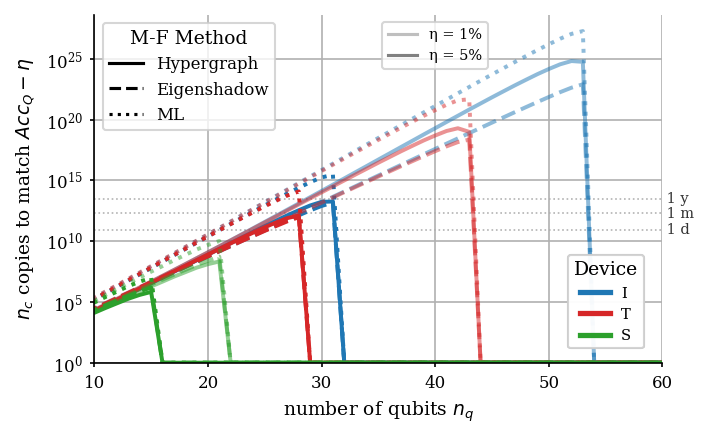

In [126]:
plot_extended_quantum_overhead_12curves(noise_type='relaxation', gamma=0.1, readout_error='1%', prep_error=0.1, extend_to_n=60)